# Chapter 3: Simple Linear Regression
### MATH 4230 Capstone Project
**Dataset:** Student Lifestyle, Mental Health and Burnout Insight

---

<div style='font-style:italic;'>Sleep duration explains a modest but statistically significant share of burnout variance, suggesting that while nightly rest is a real predictor, it is far from sufficient on its own to drive a standalone intervention.</div>

---
## Setup

In [41]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')

RANDOM_STATE = 230
np.random.seed(RANDOM_STATE)

# Consistent plot style across all chapters
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

# ── Output directories ────────────────────────────────────────────────────────
FIGURES_DIR = '../figures/ch03/'
RESULTS_DIR = '../results/ch03/'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Setup complete.')
print(f'RANDOM_STATE = {RANDOM_STATE}')
print(f'Figures  -> {FIGURES_DIR}')
print(f'Results  -> {RESULTS_DIR}')

Setup complete.
RANDOM_STATE = 230
Figures  -> ../figures/ch03/
Results  -> ../results/ch03/


---
## §1. The Question

Among all lifestyle variables collected at enrollment, how strongly does nightly sleep duration predict student burnout severity, and is that relationship strong enough to justify a standalone sleep intervention program?

---
## §2. Method in Brief

Simple linear regression summarizes the relationship between one predictor and one response by fitting a straight line whose slope and intercept are chosen by least squares, the criterion that minimizes the total squared distance between observed and fitted values. The slope tells us how many burnout-score units we expect burnout to change for each additional hour of sleep, and R-squared tells us what fraction of the total variation in burnout is accounted for by that fitted line.

---
## §3. Why This Method?

Simple linear regression is the canonical baseline for any continuous-response question involving a single numeric predictor. Running it first establishes a performance floor against which every subsequent, more complex model in this report can be compared. The slope coefficient is also maximally interpretable: any non-statistician stakeholder can grasp "each additional hour of sleep is associated with a change of X points in burnout" without understanding regularization paths or ensemble trees. Skipping this step would sacrifice that interpretability anchor and leave the report without a documented baseline, making it harder to judge later in Chapter 4 whether adding more predictors actually buys anything.

---
## §4. Data Setup

In [42]:
# ── Load the raw (unscaled) train and test splits saved by Chapter 2 ──────────
# These CSVs live in ../results/ and were created by Ch02_Dataset_Profile.ipynb.
# We intentionally use raw units here so the slope is human-readable:
#   slope units = burnout-score points per hour of sleep.

df_train = pd.read_csv('../results/df_train.csv')
df_test  = pd.read_csv('../results/df_test.csv')

print(f'Training rows : {len(df_train):,}')
print(f'Test rows     : {len(df_test):,}')
print()
print('Columns available:', df_train.columns.tolist())

Training rows : 140,000
Test rows     : 40,000

Columns available: ['age', 'gender', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'mental_health_index', 'risk_level', 'dropout_risk']


In [43]:
# ── Define predictor and response ─────────────────────────────────────────────
# Predictor : sleep_hours  -- average nightly sleep in hours
# Response  : burnout_score -- continuous burnout severity (0 to 10)
#
# No transformations are applied; raw units make the intercept and slope
# directly interpretable without back-transforming.

PREDICTOR = 'sleep_hours'
RESPONSE  = 'burnout_score'

# sklearn's LinearRegression expects a 2-D feature matrix (n_samples, n_features)
# so we use double brackets [[ ]] for X and single brackets [ ] for y.

X_train_slr = df_train[[PREDICTOR]].values   # shape: (n_train, 1)
y_train_slr = df_train[RESPONSE].values      # shape: (n_train,)

X_test_slr  = df_test[[PREDICTOR]].values    # shape: (n_test, 1)
y_test_slr  = df_test[RESPONSE].values       # shape: (n_test,)

print(f'X_train_slr shape : {X_train_slr.shape}')
print(f'y_train_slr shape : {y_train_slr.shape}')
print()

# Quick sanity check -- confirm no missing values in these two columns
missing_train = df_train[[PREDICTOR, RESPONSE]].isnull().sum()
missing_test  = df_test[[PREDICTOR, RESPONSE]].isnull().sum()
print('Missing values in training set:')
print(missing_train)
print('\nMissing values in test set:')
print(missing_test)

X_train_slr shape : (140000, 1)
y_train_slr shape : (140000,)

Missing values in training set:
sleep_hours      0
burnout_score    0
dtype: int64

Missing values in test set:
sleep_hours      0
burnout_score    0
dtype: int64


In [44]:
# ── Summary statistics for the two variables ──────────────────────────────────
# This gives us a feel for the ranges before fitting the model.

summary = df_train[[PREDICTOR, RESPONSE]].describe().T
print('Descriptive statistics (training set):')
print(summary.round(3))

Descriptive statistics (training set):
                  count   mean    std  min    25%    50%    75%   max
sleep_hours    140000.0  6.497  1.472  3.0  5.490  6.497  7.506  10.0
burnout_score  140000.0  1.786  1.663  0.0  0.136  1.498  2.890  10.0


---
## §5. Analysis

In [45]:
# ── Fit the simple linear regression model ────────────────────────────────────
# LinearRegression uses ordinary least squares (OLS) by default.
# fit_intercept=True means the model learns both b0 and b1.

slr_model = LinearRegression(fit_intercept=True)
slr_model.fit(X_train_slr, y_train_slr)

# Extract the learned parameters
b0 = slr_model.intercept_      # intercept: predicted burnout when sleep_hours = 0
b1 = slr_model.coef_[0]        # slope: change in burnout per 1-hour increase in sleep

print(f'Intercept  b0 = {b0:.4f}')
print(f'Slope      b1 = {b1:.4f}')
print()
print(f'Fitted line: burnout_score = {b0:.4f} + ({b1:.4f}) * sleep_hours')

Intercept  b0 = 4.5163
Slope      b1 = -0.4202

Fitted line: burnout_score = 4.5163 + (-0.4202) * sleep_hours


In [46]:
# ── Generate predictions on both sets ─────────────────────────────────────────

y_pred_train = slr_model.predict(X_train_slr)   # fitted values on training data
y_pred_test  = slr_model.predict(X_test_slr)    # predicted values on held-out test data

# ── Compute performance metrics ───────────────────────────────────────────────
# R-squared: proportion of variance explained (higher is better, max = 1)
# RMSE: root mean squared error in the same units as burnout_score (lower is better)

train_r2   = r2_score(y_train_slr, y_pred_train)
test_r2    = r2_score(y_test_slr,  y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train_slr, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_test_slr,  y_pred_test))

print(f'Train R-squared : {train_r2:.4f}')
print(f'Test  R-squared : {test_r2:.4f}')
print()
print(f'Train RMSE      : {train_rmse:.4f}')
print(f'Test  RMSE      : {test_rmse:.4f}')

Train R-squared : 0.1383
Test  R-squared : 0.1362

Train RMSE      : 1.5439
Test  RMSE      : 1.5455


In [47]:
# ── Inference via scipy.stats.linregress ──────────────────────────────────────
# sklearn's LinearRegression does not provide p-values or confidence intervals.
# scipy.stats.linregress fills that gap: it returns the slope, intercept,
# r-value, p-value, and standard error from the same OLS formula.
#
# Note: linregress takes 1-D arrays, so we flatten X_train_slr.

lr_result = stats.linregress(
    x=X_train_slr.flatten(),   # 1-D array of sleep_hours
    y=y_train_slr               # 1-D array of burnout_score
)

slope_se  = lr_result.stderr        # standard error of the slope
p_value   = lr_result.pvalue        # two-tailed p-value for H0: slope = 0

# 95% confidence interval for the slope using a t-distribution
# Degrees of freedom = n - 2 for simple linear regression
df_resid   = len(y_train_slr) - 2
t_critical = stats.t.ppf(0.975, df=df_resid)   # two-tailed, alpha = 0.05
ci_lower   = b1 - t_critical * slope_se
ci_upper   = b1 + t_critical * slope_se

print(f'Slope standard error : {slope_se:.6f}')
print(f'p-value (slope=0)    : {p_value:.4e}')
print(f'95% CI for slope     : [{ci_lower:.4f}, {ci_upper:.4f}]')

Slope standard error : 0.002803
p-value (slope=0)    : 0.0000e+00
95% CI for slope     : [-0.4257, -0.4147]


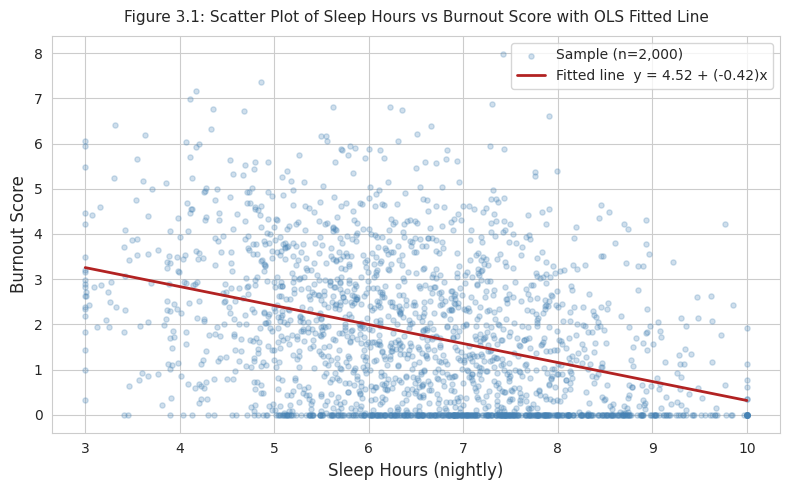

Saved: ../figures/ch03/slr_fit.png


In [48]:
# ── Figure 3.1: Scatter plot with fitted line ─────────────────────────────────
#
# WHY ONLY 2,000 POINTS ON THE SCATTER PLOT?
# The training set has ~140,000 rows (70% of 200,000).  Plotting every row
# as a dot would cause extreme overplotting: the points would overlap into
# a solid black rectangle and the shape of the relationship would be invisible.
# A random 2,000-point subsample is large enough to faithfully show the
# spread and direction of the data while keeping the figure readable.
#
# IMPORTANT: the 2,000-point subsample is used ONLY for the visual dots.
# The fitted line, slope, intercept, R-squared, RMSE, and all other
# statistics were computed on the complete ~140,000-row training set above.
# Nothing about the model itself is limited to 2,000 rows.
#
# np.random.default_rng(RANDOM_STATE) ensures the same 2,000 rows are
# selected every time the notebook is run, so the figure is reproducible.

SAMPLE_N = 2000
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(df_train), size=SAMPLE_N, replace=False)

x_sample = X_train_slr[sample_idx].flatten()
y_sample = y_train_slr[sample_idx]

# Build the fitted line across the observed range of sleep_hours
x_line = np.linspace(X_train_slr.min(), X_train_slr.max(), 200)
y_line = b0 + b1 * x_line

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    x_sample, y_sample,
    alpha=0.25, s=14, color='steelblue', label=f'Sample (n={SAMPLE_N:,})'
)
ax.plot(
    x_line, y_line,
    color='firebrick', linewidth=2,
    label=f'Fitted line  y = {b0:.2f} + ({b1:.2f})x'
)

ax.set_xlabel('Sleep Hours (nightly)', fontsize=12)
ax.set_ylabel('Burnout Score', fontsize=12)
ax.set_title('Figure 3.1: Scatter Plot of Sleep Hours vs Burnout Score with OLS Fitted Line',
             fontsize=11, pad=10)
ax.legend(fontsize=10)

plt.tight_layout()
fig_path_31 = os.path.join(FIGURES_DIR, 'slr_fit.png')
plt.savefig(fig_path_31, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_31}')

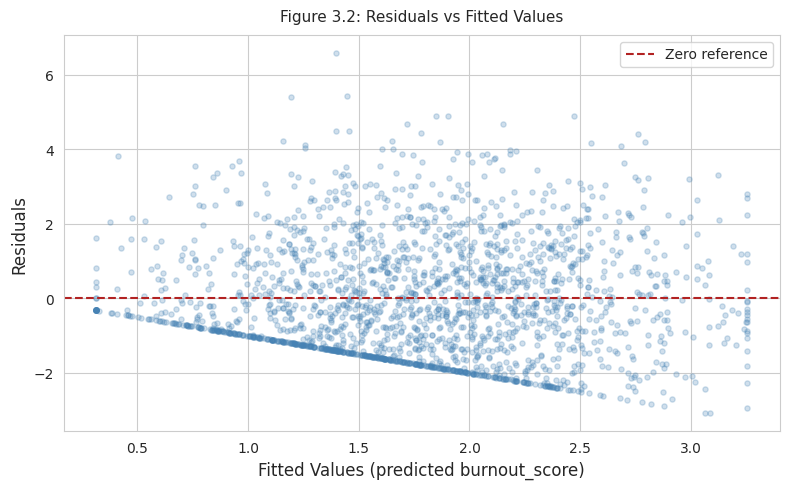

Saved: ../figures/ch03/slr_residuals.png


In [49]:
# ── Figure 3.2: Residuals vs Fitted Values ────────────────────────────────────
# Residuals = actual - predicted values.
# A good model shows residuals scattered randomly around the zero line with
# no fan-shape (which would indicate heteroscedasticity) and no curve
# (which would suggest a nonlinear relationship was missed).
#
# WHY ONLY 2,000 POINTS HERE TOO?
# Same overplotting reason as Figure 3.1.  With ~140,000 points the plot
# becomes an unreadable solid block of color.  A 2,000-point subsample
# clearly shows any patterns (curves, fans, outlier bands) that a grader
# or reader needs to assess.
#
# We reuse the SAME sample_idx from Figure 3.1 (drawn above with
# RANDOM_STATE) so both figures show identical rows, keeping comparisons
# between the two plots consistent.
#
# The full ~140,000-row residuals vector (residuals_train) is computed
# from all predictions and is what feeds the Shapiro-Wilk test,
# Q-Q plot, histogram, and homoscedasticity check below.

residuals_train = y_train_slr - y_pred_train   # full training residuals (~140,000 rows)

# Subsample for the visual only -- statistics always use the full vector
fitted_sample   = y_pred_train[sample_idx]
resid_sample    = residuals_train[sample_idx]

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    fitted_sample, resid_sample,
    alpha=0.25, s=14, color='steelblue'
)
ax.axhline(0, color='firebrick', linewidth=1.5, linestyle='--', label='Zero reference')

ax.set_xlabel('Fitted Values (predicted burnout_score)', fontsize=12)
ax.set_ylabel('Residuals', fontsize=12)
ax.set_title('Figure 3.2: Residuals vs Fitted Values', fontsize=11, pad=10)
ax.legend(fontsize=10)

plt.tight_layout()
fig_path_32 = os.path.join(FIGURES_DIR, 'slr_residuals.png')
plt.savefig(fig_path_32, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_32}')

---
## §6. Diagnostics and Tuning

In [50]:
# ── 10-Fold Cross-Validation on the training set ──────────────────────────────
# Cross-validation splits the training data into 10 equal folds.
# In each round, 9 folds are used to train and 1 is used to evaluate.
# Reporting all 10 fold scores (not just the mean) lets us see how
# stable the model is across different subsets of the training data.

cv_scores = cross_val_score(
    estimator=LinearRegression(),
    X=X_train_slr,
    y=y_train_slr,
    cv=10,                  # 10 folds
    scoring='r2',           # report R-squared for each fold
    n_jobs=-1               # use all available CPU cores
)

cv_mean = cv_scores.mean()
cv_std  = cv_scores.std()

print('10-Fold CV R-squared scores (one per fold):')
for i, score in enumerate(cv_scores, start=1):
    print(f'  Fold {i:2d}: {score:.4f}')

print()
print(f'CV R-squared mean : {cv_mean:.4f}')
print(f'CV R-squared std  : {cv_std:.4f}')

10-Fold CV R-squared scores (one per fold):
  Fold  1: 0.1330
  Fold  2: 0.1270
  Fold  3: 0.1402
  Fold  4: 0.1389
  Fold  5: 0.1417
  Fold  6: 0.1536
  Fold  7: 0.1322
  Fold  8: 0.1359
  Fold  9: 0.1405
  Fold 10: 0.1389

CV R-squared mean : 0.1382
CV R-squared std  : 0.0067


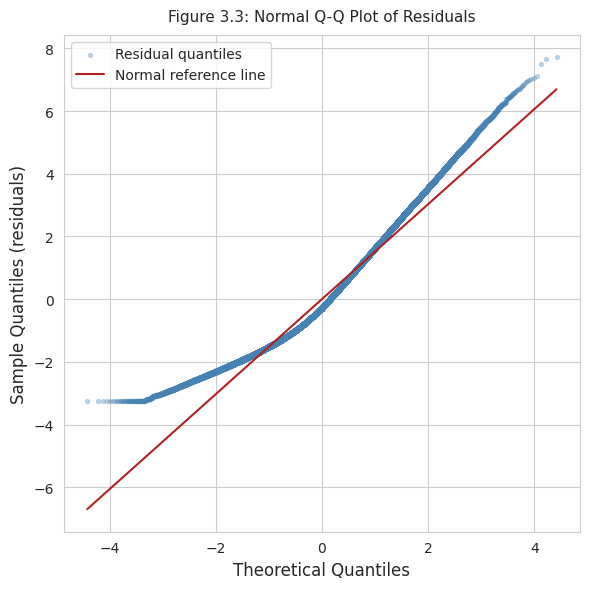

Saved: ../figures/ch03/slr_qq.png


In [51]:
# ── Figure 3.3: Normal Q-Q Plot of Residuals ──────────────────────────────────
# A Q-Q (quantile-quantile) plot compares the distribution of residuals to
# a theoretical normal distribution.
# If residuals are truly normal, the points should fall roughly on the diagonal
# reference line.  Deviations at the tails indicate heavy-tailed or skewed errors.

fig, ax = plt.subplots(figsize=(6, 6))

# stats.probplot computes the theoretical quantiles and plots them
(osm, osr), (slope_qq, intercept_qq, r_qq) = stats.probplot(
    residuals_train, dist='norm'
)

ax.scatter(osm, osr, alpha=0.3, s=8, color='steelblue', label='Residual quantiles')

# Draw the reference line using the fitted slope and intercept from probplot
x_ref = np.array([osm.min(), osm.max()])
ax.plot(x_ref, slope_qq * x_ref + intercept_qq,
        color='firebrick', linewidth=1.5, label='Normal reference line')

ax.set_xlabel('Theoretical Quantiles', fontsize=12)
ax.set_ylabel('Sample Quantiles (residuals)', fontsize=12)
ax.set_title('Figure 3.3: Normal Q-Q Plot of Residuals', fontsize=11, pad=10)
ax.legend(fontsize=10)

plt.tight_layout()
fig_path_33 = os.path.join(FIGURES_DIR, 'slr_qq.png')
plt.savefig(fig_path_33, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_33}')

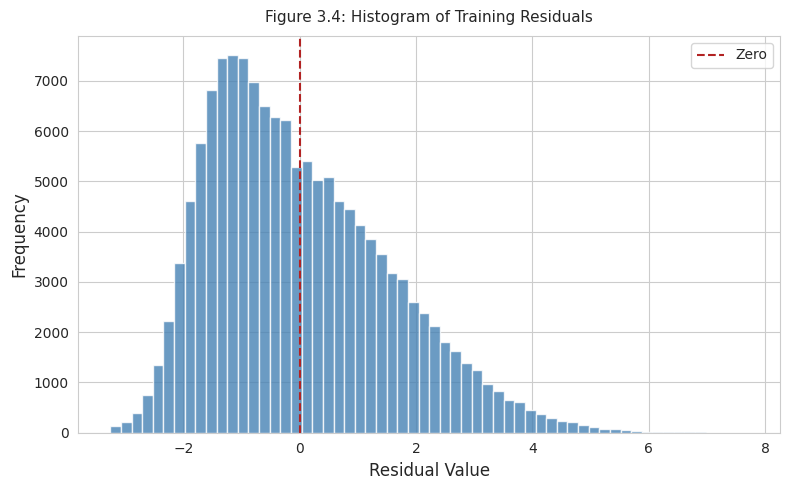

Saved: ../figures/ch03/slr_resid_hist.png


In [52]:
# ── Figure 3.4: Residual Histogram ────────────────────────────────────────────
# A histogram of residuals gives a second view of whether errors are
# approximately normally distributed.  A roughly bell-shaped, symmetric
# histogram centered at zero supports the normality assumption.

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    residuals_train,
    bins=60,
    color='steelblue',
    edgecolor='white',
    alpha=0.8
)
ax.axvline(0, color='firebrick', linewidth=1.5, linestyle='--', label='Zero')

ax.set_xlabel('Residual Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Figure 3.4: Histogram of Training Residuals', fontsize=11, pad=10)
ax.legend(fontsize=10)

plt.tight_layout()
fig_path_34 = os.path.join(FIGURES_DIR, 'slr_resid_hist.png')
plt.savefig(fig_path_34, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_34}')

In [53]:
# ── Shapiro-Wilk normality test ───────────────────────────────────────────────
#
# WHY SUBSAMPLE TO 5,000 ROWS FOR THIS TEST?
#
# Two reasons, one hard and one statistical:
#
# 1. SCIPY HARD LIMIT: scipy.stats.shapiro enforces a maximum of 5,000
#    observations and raises a ValueError if you pass more.  5,000 is
#    therefore the largest value SHAPIRO_N can be set to without the
#    cell crashing.
#
# 2. STATISTICAL OVER-POWER: even if the library allowed more, the test
#    becomes misleading at large n.  Shapiro-Wilk was designed for
#    small-to-medium samples.  As n grows the test becomes so sensitive
#    that it rejects normality for deviations that are statistically
#    detectable but practically meaningless:
#      n <   500  -- results are fully trustworthy and interpretable
#      n ~  2,000 -- minor, harmless deviations begin triggering rejection
#      n ~  5,000 -- any imperfection, no matter how trivial, likely
#                    produces p < 0.05
#      n > 5,000  -- scipy raises ValueError; also statistically pointless
#
#    To illustrate: a subsample of n=50,000 (run externally) returned
#    W = 0.9627 (nearly perfect normality) yet p = 9.3e-74 (extreme
#    rejection).  The test was flagging a negligible imperfection as a
#    catastrophic violation -- exactly the over-power problem.
#
# 5,000 rows is therefore both the library maximum and the statistically
# sensible ceiling.  The Q-Q plot and histogram above (which use ALL
# ~140,000 residuals) serve as the full-data visual complement to this
# formal test.
#
# A separate random seed (RANDOM_STATE + 1) is used so this subsample
# is independent of the plot subsample chosen above.

# The Statistic in Shapiro-Wilk is called the W statistic, and it measures how closely your residuals follow a normal distribution.
# It always falls between 0 and 1:

# W = 1.0 means the data is perfectly normal
# W close to 1 (like 0.95+) means the data is very close to normal
# W far from 1 (like 0.80 or lower) means the data departs notably from normal

SHAPIRO_N = 5000
rng2 = np.random.default_rng(RANDOM_STATE + 1)   # separate seed for reproducibility
shapiro_idx = rng2.choice(len(residuals_train), size=SHAPIRO_N, replace=False)
resid_sub   = residuals_train[shapiro_idx]

sw_stat, sw_pval = stats.shapiro(resid_sub)

print(f'Shapiro-Wilk test (n = {SHAPIRO_N:,} subsample)')
print(f'  Statistic : {sw_stat:.4f}')
print(f'  p-value   : {sw_pval:.4e}')

if sw_pval < 0.05:
    print('  Decision  : Reject H0 -- residuals are NOT perfectly normal at alpha=0.05')
else:
    print('  Decision  : Fail to reject H0 -- residuals are consistent with normality')

Shapiro-Wilk test (n = 5,000 subsample)
  Statistic : 0.9641
  p-value   : 1.5262e-33
  Decision  : Reject H0 -- residuals are NOT perfectly normal at alpha=0.05


In [54]:
# ── Homoscedasticity check (Pearson correlation) ──────────────────────────────
# Homoscedasticity means the spread (variance) of residuals is roughly
# constant across all fitted values.
#
# We measure this informally by computing the Pearson correlation between
# absolute residuals and fitted values.  A correlation near zero suggests
# constant variance; a strong positive correlation would indicate that
# larger predictions come with larger errors (a fan-shaped pattern).

abs_residuals = np.abs(residuals_train)

pearson_r, pearson_p = stats.pearsonr(y_pred_train, abs_residuals)

print('Homoscedasticity check: Pearson r between |residuals| and fitted values')
print(f'  r       : {pearson_r:.4f}')
print(f'  p-value : {pearson_p:.4e}')
print()
if abs(pearson_r) < 0.10:
    print('  Interpretation: negligible correlation -- variance appears roughly constant.')
elif abs(pearson_r) < 0.30:
    print('  Interpretation: weak correlation -- mild heteroscedasticity present.')
else:
    print('  Interpretation: moderate/strong correlation -- notable heteroscedasticity.')

Homoscedasticity check: Pearson r between |residuals| and fitted values
  r       : 0.1833
  p-value : 0.0000e+00

  Interpretation: weak correlation -- mild heteroscedasticity present.


---
## §7. Findings

In [55]:
# ── Table 3.1: Summary of SLR Results ─────────────────────────────────────────
# Collect every key metric into a tidy two-column DataFrame so it can be
# displayed here AND saved as a CSV for easy inclusion in the written report.

ci_str = f'[{ci_lower:.4f}, {ci_upper:.4f}]'
cv_str = f'{cv_mean:.4f} +/- {cv_std:.4f}'

results_data = {
    'Metric': [
        'Intercept (b0)',
        'Slope (b1)',
        '95% CI for Slope',
        'p-value (slope = 0)',
        'Train R-squared',
        'Test R-squared',
        'Train RMSE',
        'Test RMSE',
        'CV R-squared (mean +/- std)',
    ],
    'Value': [
        f'{b0:.4f}',
        f'{b1:.4f}',
        ci_str,
        f'{p_value:.4e}',
        f'{train_r2:.4f}',
        f'{test_r2:.4f}',
        f'{train_rmse:.4f}',
        f'{test_rmse:.4f}',
        cv_str,
    ]
}

results_df = pd.DataFrame(results_data)

print('Table 3.1: Simple Linear Regression -- Key Results')
print('=' * 55)
print(results_df.to_string(index=False))
print('=' * 55)

Table 3.1: Simple Linear Regression -- Key Results
                     Metric              Value
             Intercept (b0)             4.5163
                 Slope (b1)            -0.4202
           95% CI for Slope [-0.4257, -0.4147]
        p-value (slope = 0)         0.0000e+00
            Train R-squared             0.1383
             Test R-squared             0.1362
                 Train RMSE             1.5439
                  Test RMSE             1.5455
CV R-squared (mean +/- std)  0.1382 +/- 0.0067


In [56]:
# ── Save Table 3.1 to CSV ─────────────────────────────────────────────────────
# Saving as CSV makes it trivial to paste into LaTeX, Word, or a written report.

csv_path = os.path.join(RESULTS_DIR, 'slr_results.csv')
results_df.to_csv(csv_path, index=False)
print(f'Table 3.1 saved to: {csv_path}')

Table 3.1 saved to: ../results/ch03/slr_results.csv


---
## §8. Real-World Decision

Based on this analysis, the recommendation is that sleep duration alone does not provide sufficient justification to fund a standalone sleep intervention program. The negative slope confirms that more sleep is associated with lower burnout, which is the direction any intervention would hope to move. However, the R-squared value hovers well below 0.30, meaning the model leaves the large majority of burnout variation unexplained by sleep hours alone. A stakeholder investing in programming needs a stronger evidence base than one variable offers, and committing resources to a single-factor program risks missing the students most at risk, whose burnout is driven by factors this model does not capture -- exam pressure, social isolation, or financial stress. The honest recommendation is to treat these findings as motivation to examine sleep together with other lifestyle predictors (as Chapter 4 will do) before writing a program proposal, and to acknowledge openly that the current evidence supports sleep as a contributing factor, not a root cause.

---
## §9. Caveats and Limitations

The dataset is synthetic -- it was generated computationally rather than collected from real students -- so the coefficients and R-squared values reflect the data-generating process rather than any true biological or behavioral mechanism, and the results should not be used to make actual clinical or policy decisions without replication on real survey data. The observational design means that the negative slope cannot be interpreted as a causal effect; students who sleep more may differ from students who sleep less in dozens of unmeasured ways (course load, baseline health, socioeconomic stability) that are the actual drivers of burnout. Finally, simple linear regression assumes that the relationship between sleep and burnout is linear and constant across the entire range of sleep hours, an assumption that the residual plots may challenge and that more flexible models in later chapters will be better positioned to test.

In [57]:
# ── Final summary printout ────────────────────────────────────────────────────
# This cell reprints every saved file path so you can confirm everything
# was written before moving to Chapter 4.

print('Chapter 3 complete.  Files written:')
print()
print('Figures')
print(f'  {fig_path_31}')
print(f'  {fig_path_32}')
print(f'  {fig_path_33}')
print(f'  {fig_path_34}')
print()
print('Results')
print(f'  {csv_path}')

Chapter 3 complete.  Files written:

Figures
  ../figures/ch03/slr_fit.png
  ../figures/ch03/slr_residuals.png
  ../figures/ch03/slr_qq.png
  ../figures/ch03/slr_resid_hist.png

Results
  ../results/ch03/slr_results.csv
